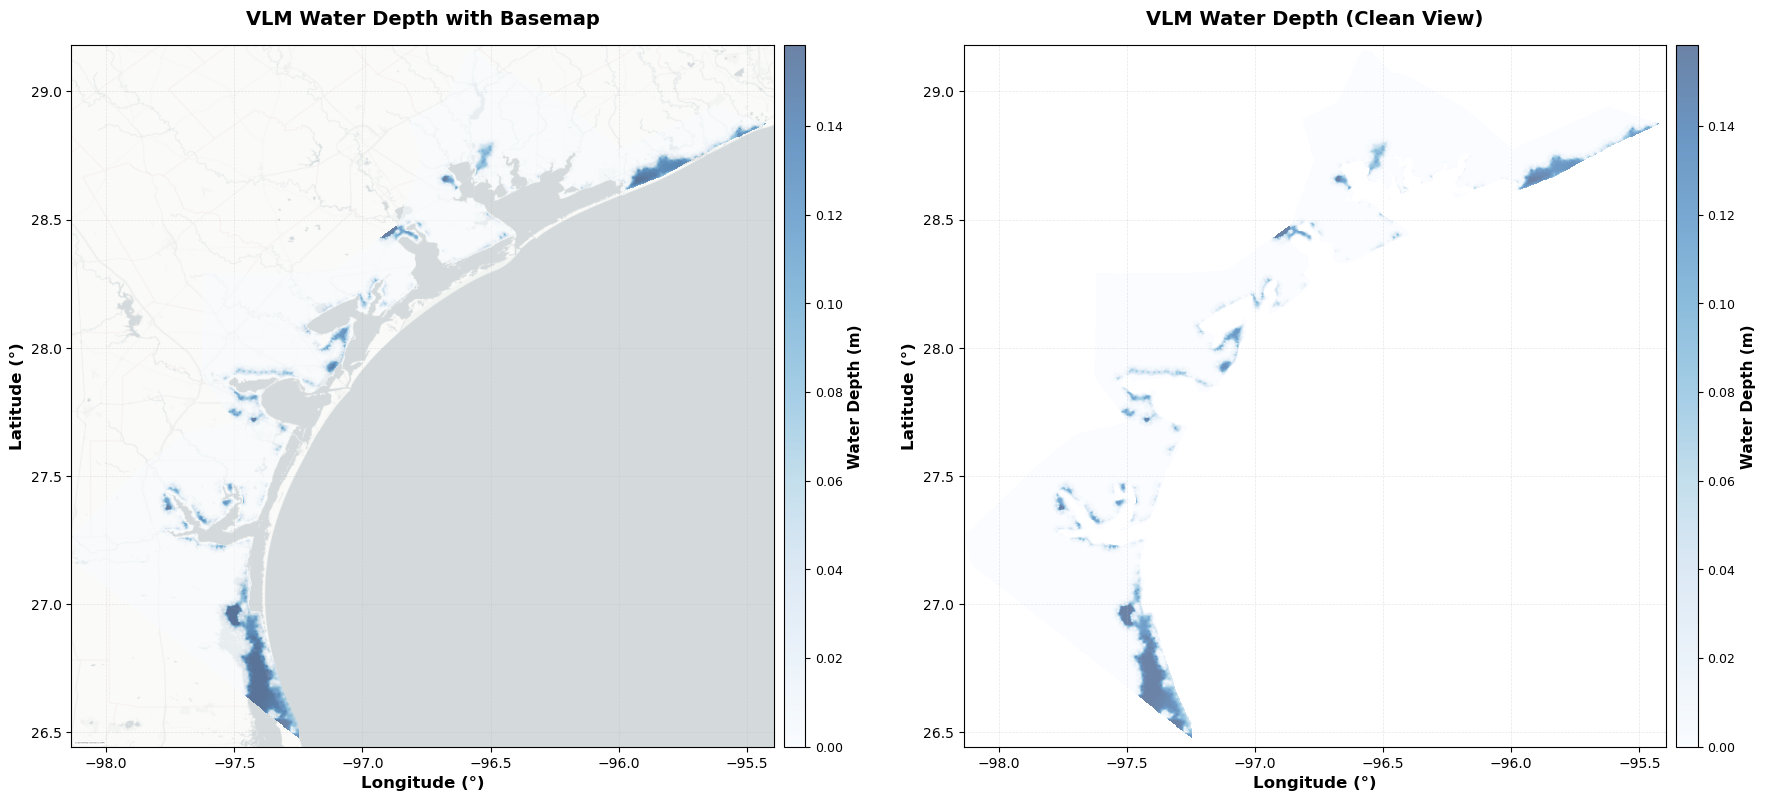

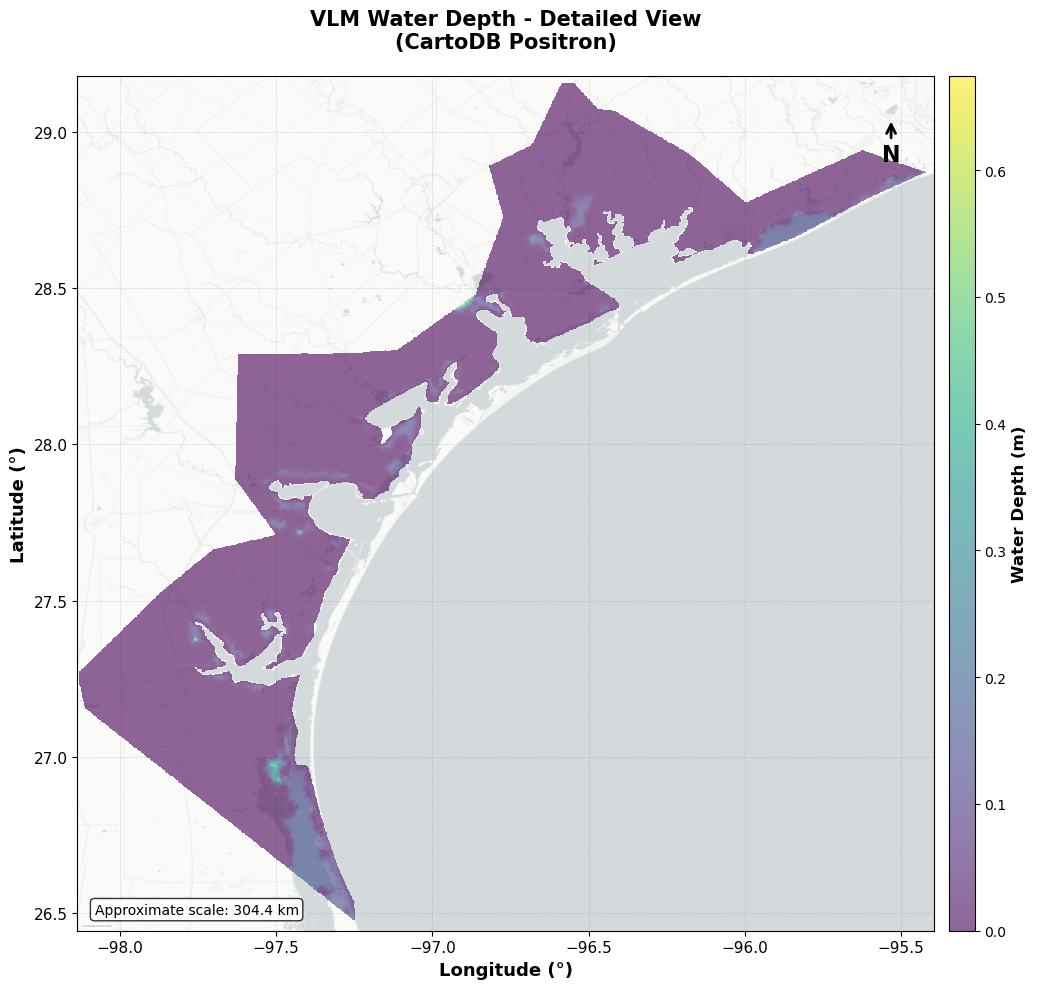

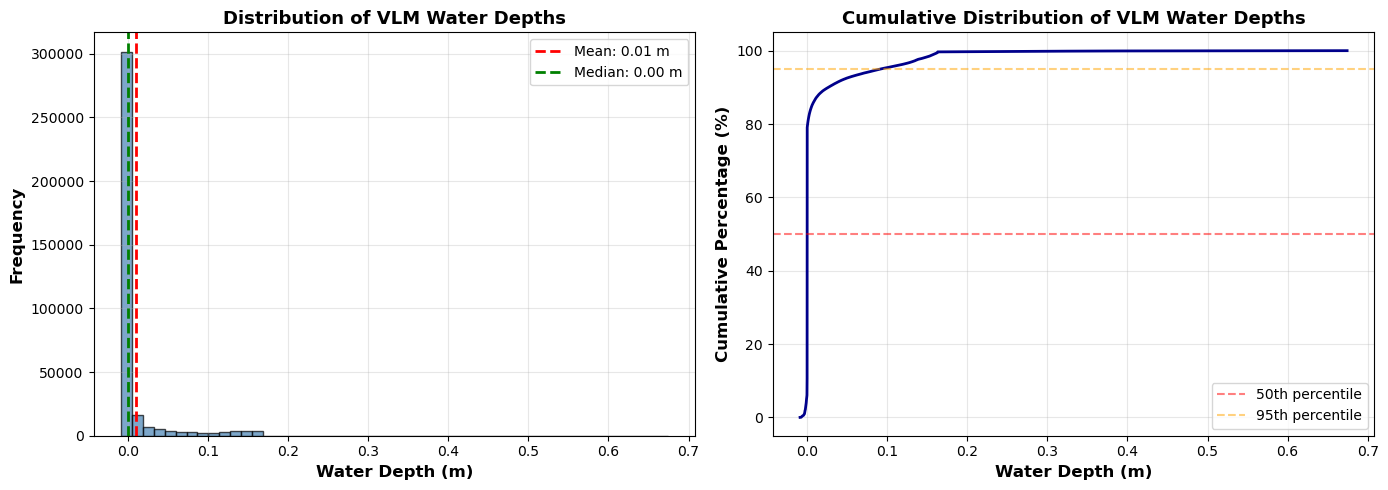

In [9]:
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import tempfile
import os

# File path
vlm_raster = r"D:\Phd Research\Final_Raster\VLM_only_depth.tif"

# Destination CRS (WGS84)
DST_CRS = "EPSG:4326"

# Basemap zoom level
BASEMAP_ZOOM = 10

# Read and reproject raster to WGS84
with rasterio.open(vlm_raster) as src:
    # Calculate transform for WGS84
    transform, width, height = calculate_default_transform(
        src.crs, DST_CRS, src.width, src.height, *src.bounds
    )
    
    # Create metadata for reprojected raster
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': DST_CRS,
        'transform': transform,
        'width': width,
        'height': height
    })
    
    # Create temporary file for reprojected raster
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.tif')
    temp_path = temp_file.name
    temp_file.close()
    
    # Reproject and write to temporary file
    with rasterio.open(temp_path, 'w', **kwargs) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=DST_CRS,
            resampling=Resampling.bilinear
        )

# Read reprojected raster
with rasterio.open(temp_path) as src:
    vlm_data = src.read(1)
    
    # Handle NoData values
    nodata = src.nodata
    if nodata is not None:
        vlm_data = np.where(vlm_data == nodata, np.nan, vlm_data)
    
    transform = src.transform
    bounds = src.bounds
    crs = src.crs

# Calculate statistics
valid_data = vlm_data[~np.isnan(vlm_data)]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# =============== Plot 1: With Basemap ===============

# Read raster for plotting
with rasterio.open(temp_path) as src:
    # Create custom colormap (blue scale for water depth)
    colors = ['#f7fbff', '#deebf7', '#c6dbef', '#9ecae1', '#6baed6', 
              '#4292c6', '#2171b5', '#08519c', '#08306b']
    n_bins = 256
    cmap = LinearSegmentedColormap.from_list('water_depth', colors, N=n_bins)
    
    # Plot raster with transparency
    im1 = show(src, ax=ax1, cmap=cmap, transform=src.transform, 
               vmin=0, vmax=np.percentile(valid_data, 99), zorder=2, alpha=0.6)
    
    # Add basemap
    try:
        ctx.add_basemap(
            ax1, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
            zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1
        )
    except:
        pass

# Format ax1
ax1.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
ax1.set_title('VLM Water Depth with Basemap', 
              fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax1.tick_params(labelsize=10)

# Add colorbar for ax1
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.1)
cbar1 = plt.colorbar(im1.get_images()[0], cax=cax1)
cbar1.set_label('Water Depth (m)', fontsize=11, fontweight='bold')
cbar1.ax.tick_params(labelsize=9)

# =============== Plot 2: Clean map without basemap ===============

with rasterio.open(temp_path) as src:
    # Plot raster with transparency
    im2 = show(src, ax=ax2, cmap=cmap, transform=src.transform,
               vmin=0, vmax=np.percentile(valid_data, 99), alpha=0.6)

# Format ax2
ax2.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
ax2.set_title('VLM Water Depth (Clean View)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax2.tick_params(labelsize=10)

# Add colorbar for ax2
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.1)
cbar2 = plt.colorbar(im2.get_images()[0], cax=cax2)
cbar2.set_label('Water Depth (m)', fontsize=11, fontweight='bold')
cbar2.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('VLM_depth_with_basemap.png', dpi=300, bbox_inches='tight')
plt.show()

# =============== Create additional detailed map ===============

fig2, ax3 = plt.subplots(figsize=(14, 10))

with rasterio.open(temp_path) as src:
    # Use a different colormap for better visualization
    cmap2 = plt.cm.viridis
    cmap2.set_bad('white', alpha=0)  # Set NaN to transparent
    
    # Plot with percentile for better visualization
    depth_range = np.max(valid_data) - np.min(valid_data)
    if depth_range > 5:
        vmax_val = np.percentile(valid_data, 95)
    else:
        vmax_val = np.max(valid_data)
    
    im3 = show(src, ax=ax3, cmap=cmap2, transform=src.transform,
               vmin=0, vmax=vmax_val, zorder=2, alpha=0.6)
    
    # Add basemap
    try:
        ctx.add_basemap(
            ax3, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
            zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1
        )
        basemap_type = "CartoDB Positron"
    except:
        basemap_type = "No Basemap"

# Format ax3
ax3.set_xlabel('Longitude (°)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Latitude (°)', fontsize=13, fontweight='bold')
ax3.set_title(f'VLM Water Depth - Detailed View\n({basemap_type})', 
              fontsize=15, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5, color='gray')
ax3.tick_params(labelsize=11)

# Add colorbar
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="3%", pad=0.15)
cbar3 = plt.colorbar(im3.get_images()[0], cax=cax3)
cbar3.set_label('Water Depth (m)', fontsize=12, fontweight='bold')
cbar3.ax.tick_params(labelsize=10)

# Add north arrow
arrow_props = dict(facecolor='black', arrowstyle='->', lw=2)
ax3.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
            xycoords='axes fraction', fontsize=16, fontweight='bold',
            ha='center', arrowprops=arrow_props)

# Add scale information
extent = ax3.get_xlim()
scale_km = (extent[1] - extent[0]) * 111  # rough conversion to km
ax3.text(0.02, 0.02, f'Approximate scale: {scale_km:.1f} km',
        transform=ax3.transAxes, fontsize=10, 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('VLM_depth_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

# =============== Create histogram of depths ===============

fig3, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax4.hist(valid_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Water Depth (m)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax4.set_title('Distribution of VLM Water Depths', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axvline(np.mean(valid_data), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {np.mean(valid_data):.2f} m')
ax4.axvline(np.median(valid_data), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(valid_data):.2f} m')
ax4.legend(fontsize=10)

# Cumulative distribution
sorted_data = np.sort(valid_data)
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data) * 100
ax5.plot(sorted_data, cumulative, color='darkblue', linewidth=2)
ax5.set_xlabel('Water Depth (m)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
ax5.set_title('Cumulative Distribution of VLM Water Depths', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.axhline(50, color='red', linestyle='--', alpha=0.5, label='50th percentile')
ax5.axhline(95, color='orange', linestyle='--', alpha=0.5, label='95th percentile')
ax5.legend(fontsize=10)

plt.tight_layout()
plt.savefig('VLM_depth_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Clean up temporary file
os.unlink(temp_path)